# V. Stacked LSTM Decoder (256 units → 128 units)
Larger architecture variant for comparison.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import warnings; warnings.filterwarnings('ignore')

df = pd.read_csv('../dl_service/data/cattle_training_data.csv', parse_dates=['timestamp'])
FEATURES = ['temperature', 'humidity', 'heartRate', 'distance', 'hour', 'day_of_week']
SEQUENCE_LENGTH = 30
N_FEATURES = len(FEATURES)

df_normal = df[df['is_anomaly']==0].dropna(subset=FEATURES).sort_values(['cattle_id','timestamp']).reset_index(drop=True)
scaler = MinMaxScaler(feature_range=(0,1))
scaled = scaler.fit_transform(df_normal[FEATURES].values)

def create_sequences(data, sl):
    return np.array([data[i:i+sl] for i in range(len(data)-sl+1)], dtype=np.float32)

all_seq = create_sequences(scaled, SEQUENCE_LENGTH)
print(f"Sequences: {all_seq.shape}")

Sequences: (20926, 30, 6)


In [2]:
MODEL_NAME = 'Stacked LSTM (256→128)'
model = models.Sequential([
    layers.Input(shape=(SEQUENCE_LENGTH, N_FEATURES)),
    layers.LSTM(256, activation='tanh', return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(128, activation='tanh', return_sequences=False),
    layers.Dropout(0.2),
    layers.RepeatVector(SEQUENCE_LENGTH),
    layers.LSTM(128, activation='tanh', return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(256, activation='tanh', return_sequences=True),
    layers.TimeDistributed(layers.Dense(N_FEATURES)),
])
model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 256)        │       269,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 6)          │         1,542 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993,798 (3.79 MB)

 Trainable params: 993,798 (3.79 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(all_seq, all_seq, epochs=100, batch_size=64, validation_split=0.15,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss',patience=12,restore_best_weights=True),
               callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=6,min_lr=1e-6)], verbose=1)
train_recon = model.predict(all_seq, verbose=0)
train_errors = np.mean(np.square(all_seq - train_recon), axis=(1,2))
print(f"Mean Error: {np.mean(train_errors):.6f}")

Epoch 1/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 144s 487ms/step - loss: 0.0256 - val_loss: 0.0150 - learning_rate: 0.0010
Epoch 2/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 126s 455ms/step - loss: 0.0147 - val_loss: 0.0136 - learning_rate: 0.0010
Epoch 3/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 133s 480ms/step - loss: 0.0135 - val_loss: 0.0123 - learning_rate: 0.0010
Epoch 4/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 133s 478ms/step - loss: 0.0129 - val_loss: 0.0127 - learning_rate: 0.0010
Epoch 5/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 130s 469ms/step - loss: 0.0126 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 6/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 128s 459ms/step - loss: 0.0126 - val_loss: 0.0120 - learning_rate: 0.0010
Epoch 7/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 114s 411ms/step - loss: 0.0125 - val_loss: 0.0119 - learning_rate: 0.0010
Epoch 8/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 106s 382ms/step - loss: 0.0124 - val_loss: 0.0120 - learning_rate: 0.0010
Epoch 9/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 98s 354ms/step - loss: 0.0121 - val_los

In [ ]:
# Evaluate on full dataset
df_all = df.dropna(subset=FEATURES).sort_values(['cattle_id','timestamp']).reset_index(drop=True)
test_scaled = scaler.transform(df_all[FEATURES].values)
test_seq = create_sequences(test_scaled, SEQUENCE_LENGTH)
test_recon = model.predict(test_seq, verbose=0)
test_errors = np.mean(np.square(test_seq - test_recon), axis=(1,2))
threshold = float(np.percentile(train_errors, 98))
preds = (test_errors > threshold).astype(int)
actuals = df_all['is_anomaly'].values[SEQUENCE_LENGTH-1:][:len(preds)]
print(classification_report(actuals, preds, target_names=['Normal','Anomaly']))

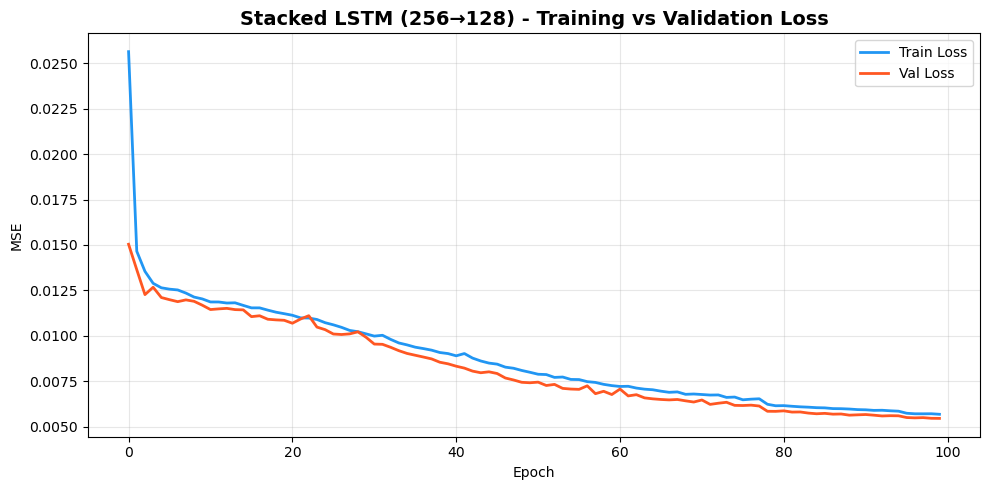

NameError: name 'threshold' is not defined

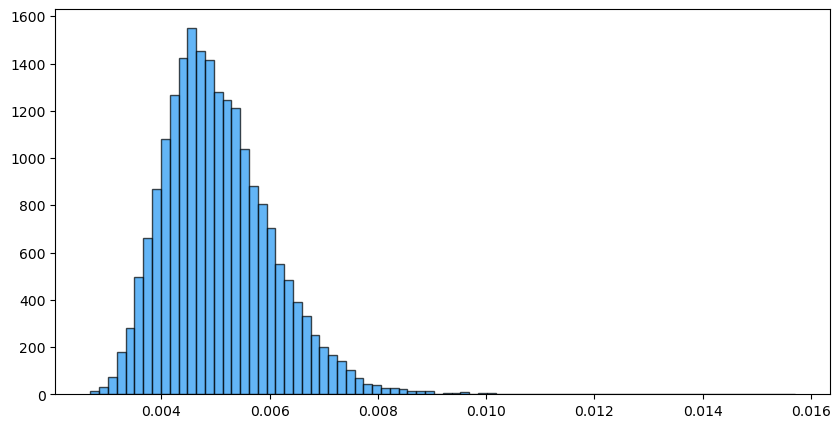

In [7]:
# Training Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss', color='#2196F3', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='#FF5722', linewidth=2)
plt.title(MODEL_NAME+' - Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Reconstruction Error
plt.figure(figsize=(10,5))
plt.hist(train_errors, bins=80, color='#2196F3', alpha=0.7, edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.4f}')
plt.title(MODEL_NAME+' - Reconstruction Error Distribution', fontsize=14, fontweight='bold')
plt.xlabel('MSE'); plt.ylabel('Frequency'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Confusion Matrix
cm = confusion_matrix(actuals, preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','Anomaly'], yticklabels=['Normal','Anomaly'])
plt.title(MODEL_NAME+' - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.tight_layout(); plt.show()

# ROC Curve
fpr,tpr,_ = roc_curve(actuals, test_errors[:len(actuals)])
roc_auc = auc(fpr,tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr, color='#2196F3', linewidth=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.title(MODEL_NAME+' - ROC Curve', fontsize=14, fontweight='bold')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"AUC Score: {roc_auc:.4f}")